# Netflix TV Shows and Movies Dataset Analysis

In [2]:
##Import Libraries
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

c:\Users\Devanshu upadhyay\Desktop\Project Work\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
##Load Dataset
d = kagglehub.dataset_download("divyaraj2006/netflix-tv-shows-and-movies")
files = os.listdir(d)
cfiles = [f for f in files if f.endswith('.csv')]
dpath = os.path.join(d, cfiles[0])
df = pd.read_csv(dpath)

In [4]:
##Explore Data
print("Head:")
print(df.head())

print("\nInfo:")
print(df.info())

print("\nSummary statistics==")
print(df.describe(include='all'))


Head:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0  25-Sep-21          2020  PG-13     90 min   
1  24-Sep-21          2021  TV-MA  2 Seasons   
2  24-Sep-21          2021  TV-MA   1 Season   
3 

In [5]:
##Check for Missing Values
print("\nMissing values per column:")
print(df.isnull().sum())



Missing values per column:
show_id          0
type             0
title            0
director        63
cast            20
country         64
date_added       0
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


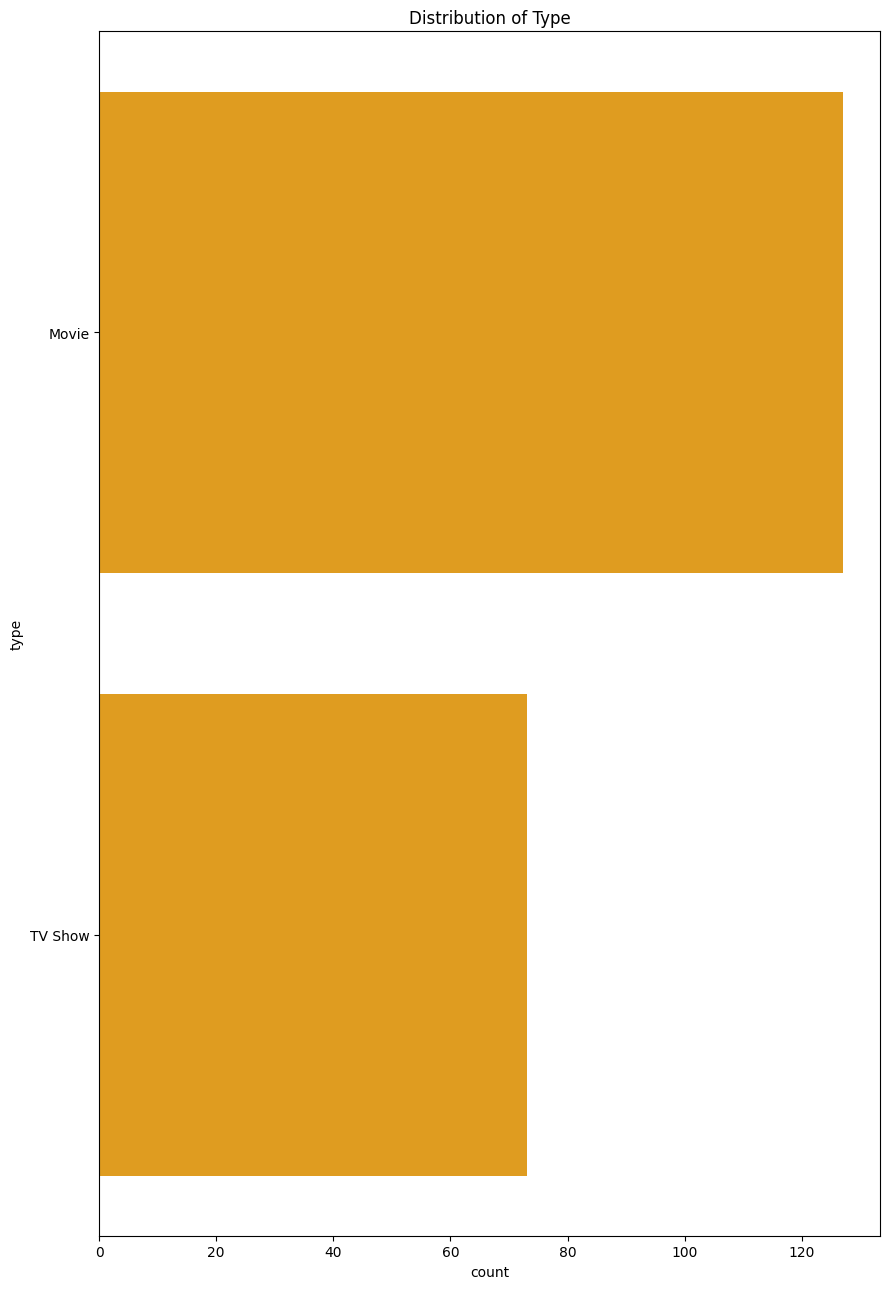

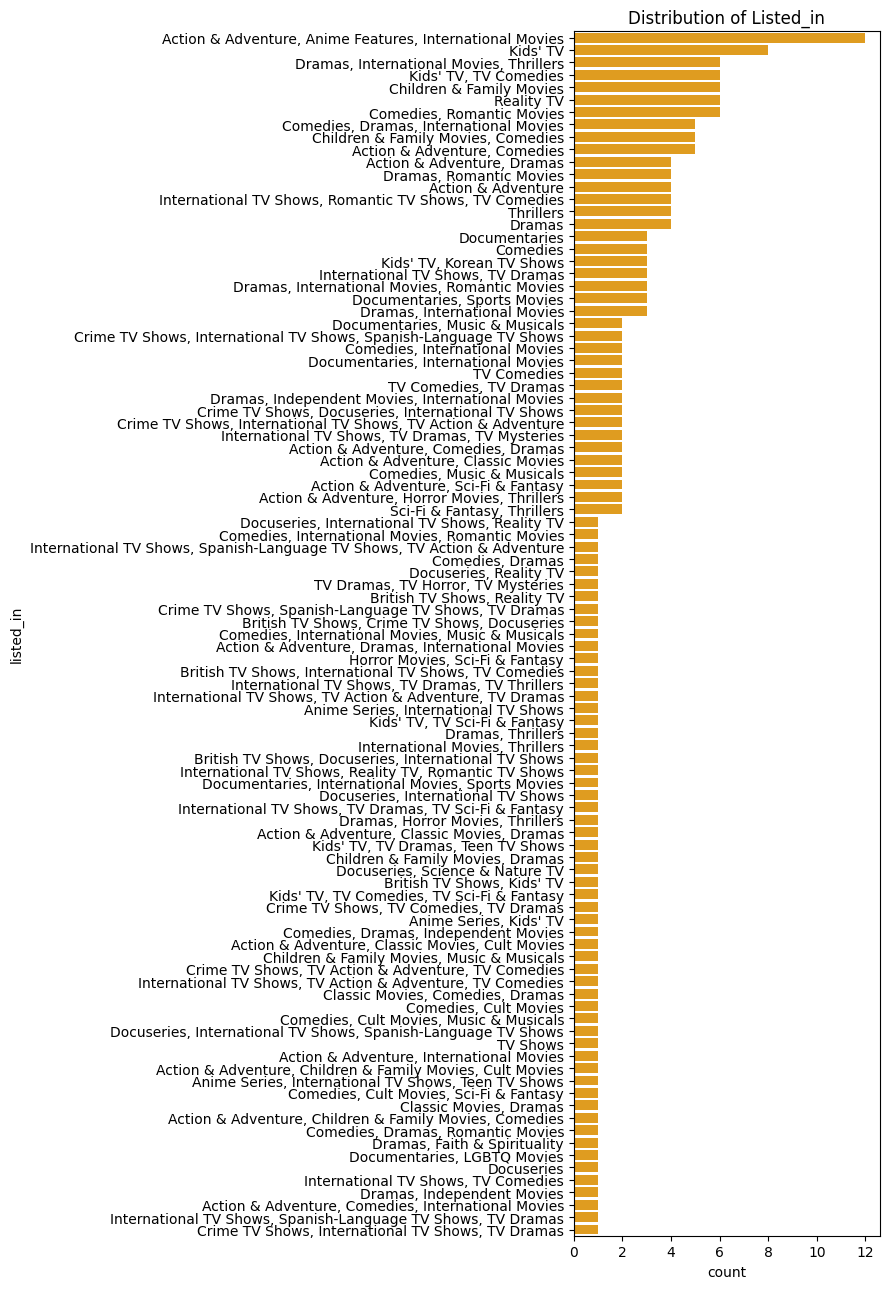

In [6]:
##Visualize Categorical Variables
for col in ['type', 'genre', 'listed_in']:
    if col in df.columns:
        plt.figure(figsize=(9, 13))
        sns.countplot(y=col, data=df, order=df[col].value_counts().index,color='orange')
        plt.title(f"Distribution of {col.capitalize()}")
        plt.tight_layout()
        plt.show()


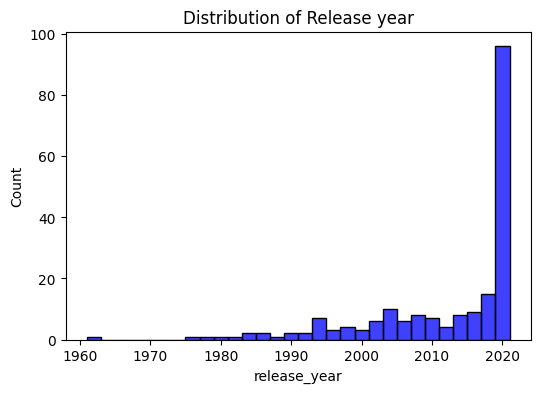

In [7]:
##Visualize Release Year or Year Columns
for col in ['release_year', 'year']:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col].dropna(), bins=30,color='blue')
        plt.title(f"Distribution of {col.replace('_',' ').capitalize()}")
        plt.show()
        break


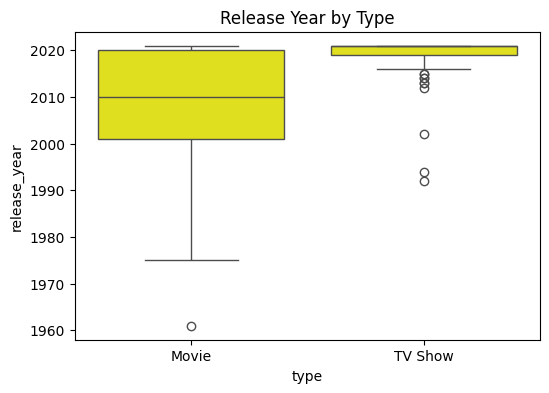

In [8]:
## Boxplot of Release Year by Type
if 'type' in df.columns and 'release_year' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='type', y='release_year', data=df,color='yellow')
    plt.title("Release Year by Type")
    plt.show()


In [9]:
##Parse Duration to Minutes
if 'duration' in df.columns:
    def parse_duration(dur):
        if pd.isna(dur):
            return np.nan
        dur = str(dur).lower()
        if "min" in dur:
            try:
                return int(dur.split(" ")[0])
            except:
                return np.nan
        elif "season" in dur:
            try:
                return int(dur.split(" ")[0]) * 45
            except:
                return np.nan
        return np.nan
    
    df['duration_mins'] = df['duration'].apply(parse_duration)


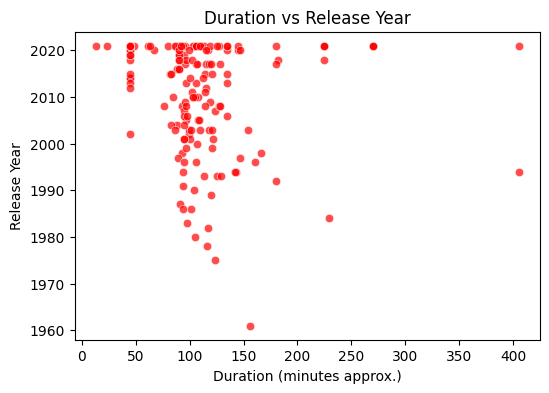

In [10]:
 ##Scatter Plot of Duration vs Release Year
if 'release_year' in df.columns and 'duration_mins' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x='duration_mins', y='release_year', data=df, alpha=0.7,color='red')
    plt.title('Duration vs Release Year')
    plt.xlabel('Duration (minutes approx.)')
    plt.ylabel('Release Year')
    plt.show()


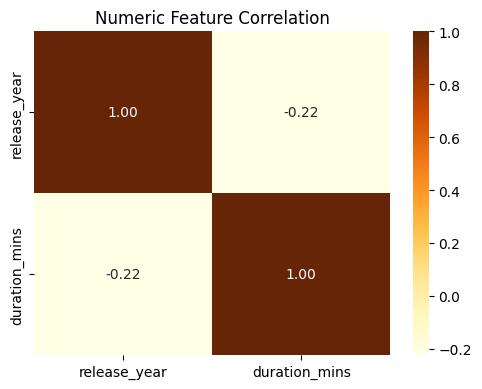

Correlation Matrix:
                release_year  duration_mins
release_year       1.000000      -0.224071
duration_mins     -0.224071       1.000000


In [11]:
## Numeric Feature Correlation Heatmap
numeric_cols = df.select_dtypes(include='number').columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(5, 4))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlOrBr')
    plt.title("Numeric Feature Correlation")
    plt.tight_layout()
    plt.show()
    print("Correlation Matrix:\n", corr)


In [12]:
##Outlier Detection
if 'release_year' in df.columns:
    z_scores = np.abs(stats.zscore(df['release_year'].dropna()))
    outlier_count = (z_scores > 3).sum()
    print(f"Outliers in release_year (z>3): {outlier_count}")

if 'duration_mins' in df.columns:
    z_scores = np.abs(stats.zscore(df['duration_mins'].dropna()))
    outlier_count = (z_scores > 3).sum()
    print(f"Outliers in duration_mins (z>3): {outlier_count}")


Outliers in release_year (z>3): 2
Outliers in duration_mins (z>3): 5


In [13]:
## Group-wise Release Year Statistics
if 'type' in df.columns and 'release_year' in df.columns:
    grouped = df.groupby('type')['release_year'].agg(['count','mean','min','max'])
    print("\nGroup-wise release year stats by type:\n", grouped)



Group-wise release year stats by type:
          count         mean   min   max
type                                   
Movie      127  2008.448819  1961  2021
TV Show     73  2018.808219  1992  2021


Linear Regression R^2 on test: 0.1328751595067742


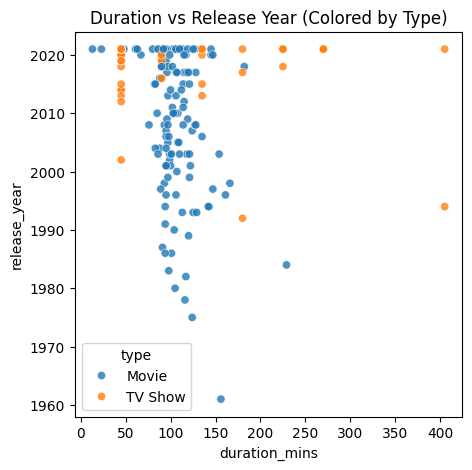

In [14]:
## Linear Regression to Predict Release Year
if 'release_year' in df.columns and 'duration_mins' in df.columns:
    df_reg = df.dropna(subset=['release_year', 'duration_mins'])
    le = LabelEncoder()
    if 'type' in df_reg.columns:
        df_reg['type_encoded'] = le.fit_transform(df_reg['type'])

        X = df_reg[['duration_mins', 'type_encoded']]
        y = df_reg['release_year']

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        reg = LinearRegression()
        reg.fit(X_train, y_train)
        print("Linear Regression R^2 on test:", reg.score(X_test, y_test))

        plt.figure(figsize=(5,5))
        sns.scatterplot(x='duration_mins', y='release_year', hue='type', data=df_reg, alpha=0.8)
        plt.title("Duration vs Release Year (Colored by Type)")
        plt.show()
    else:
        print("No 'type' column; regression run only on duration_mins.")
